In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

In [2]:
train_dir = r"E:\CNN_SKIN_DATASET_TRAIN_TEST\train"
test_dir = r"E:\CNN_SKIN_DATASET_TRAIN_TEST\val"

In [3]:
IMG_SIZE = 160
BATCH_SIZE = 16

In [4]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [5]:
train_generator = train_datagen.flow_from_directory(train_dir
    ,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 20262 images belonging to 8 classes.


In [6]:
# checking the classes of dataset for output
NUM_CLASSES = len(train_generator.class_indices)
NUM_CLASSES

8

In [7]:
#computing the weight
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_generator.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(3.6547619047619047), 1: np.float64(0.9528781038374717), 2: np.float64(1.2066460219151978), 3: np.float64(13.260471204188482), 4: np.float64(0.2458980582524272), 5: np.float64(0.700235001382361), 6: np.float64(5.045318725099602), 7: np.float64(12.538366336633663)}


In [8]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5069 images belonging to 8 classes.


In [9]:
# building the model 
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
# Freeze all  layers
for layer in base_model.layers:
    layer.trainable = False

In [11]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
output = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.models.Model(base_model.input, output)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [13]:
history = model.fit(
    train_generator,
    epochs=15,
    class_weight=class_weights
)


Epoch 1/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1578s 1s/step - accuracy: 0.3775 - loss: 1.7779
Epoch 2/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1105s 872ms/step - accuracy: 0.4501 - loss: 1.4904
Epoch 3/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1100s 868ms/step - accuracy: 0.4712 - loss: 1.3937
Epoch 4/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1118s 883ms/step - accuracy: 0.4972 - loss: 1.3289
Epoch 5/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 890s 702ms/step - accuracy: 0.5116 - loss: 1.2641
Epoch 6/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 823s 650ms/step - accuracy: 0.5110 - loss: 1.2516
Epoch 7/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 806s 636ms/step - accuracy: 0.5227 - loss: 1.2082
Epoch 8/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 869s 686ms/step - accuracy: 0.5232 - loss: 1.2075
Epoch 9/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1033s 816ms/step - accuracy: 0.5338 - loss: 1.1600
Epoch 10/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1161s 916ms/step - accuracy: 0.5415 - loss: 1.1326
Epoch 11/15
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 870s 686ms/step - accuracy: 0.541

In [14]:
loss, accuracy = model.evaluate(test_generator)
print("Test Accuracy:", accuracy)

317/317 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.5597 - loss: 1.1813
Test Accuracy: 0.559676468372345


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [16]:
prediction = model.predict(test_generator)

317/317 ━━━━━━━━━━━━━━━━━━━━ 225s 696ms/step


In [17]:
y_pred = np.argmax(prediction, axis=1)
y_true = test_generator.classes

In [18]:
class_labels = list(test_generator.class_indices.keys())

In [19]:
cm = confusion_matrix(y_true, y_pred)

In [20]:
cm

array([[  96,   26,   19,    4,    2,    7,   18,    2],
       [ 103,  346,   67,   11,   19,   15,   74,   30],
       [  58,   30,  290,   10,   47,   53,   25,   12],
       [   1,    9,    8,   16,    4,    1,    3,    6],
       [  16,  119,  371,   63, 1538,  316,   32,  120],
       [  50,   47,  139,    9,  128,  462,   40,   30],
       [  16,   38,   10,    5,    2,    8,   47,    0],
       [   0,    3,    1,    0,    1,    1,    3,   42]])

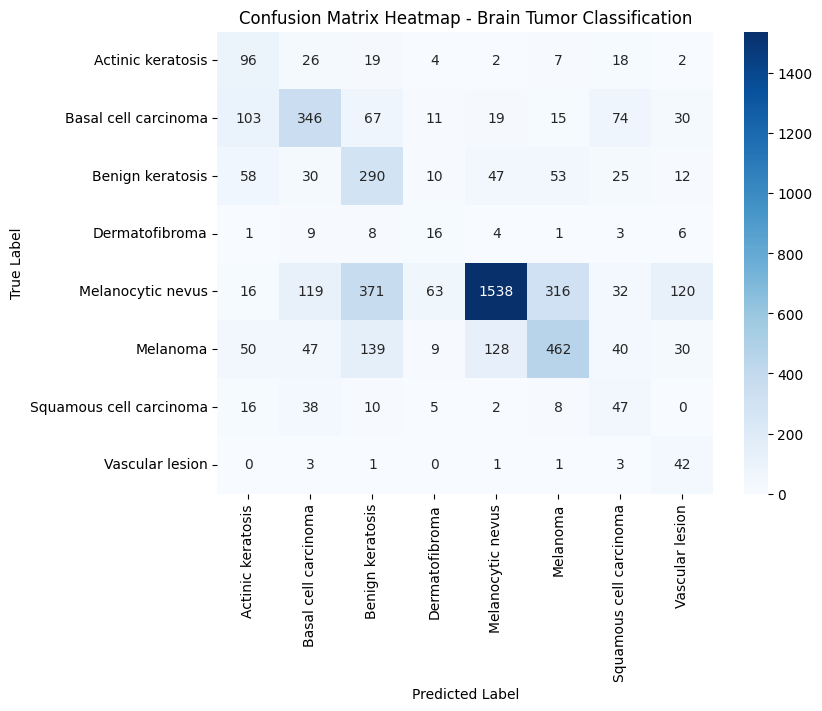

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap - Brain Tumor Classification")
plt.show()


In [22]:
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

                         precision    recall  f1-score   support

      Actinic keratosis       0.28      0.55      0.37       174
   Basal cell carcinoma       0.56      0.52      0.54       665
       Benign keratosis       0.32      0.55      0.41       525
         Dermatofibroma       0.14      0.33      0.19        48
      Melanocytic nevus       0.88      0.60      0.71      2575
               Melanoma       0.54      0.51      0.52       905
Squamous cell carcinoma       0.19      0.37      0.26       126
        Vascular lesion       0.17      0.82      0.29        51

               accuracy                           0.56      5069
              macro avg       0.39      0.53      0.41      5069
           weighted avg       0.67      0.56      0.59      5069

